# VAR and DeepAR Fit

This notebook fits forecasting models to the simulated DGP datasets generated.

For now, this notebook only fits the classical VAR model. The DeepAR section is left as a stub and will be added later after the VAR/residual/innovation pipeline is validated.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.append(str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.utils.seeds import set_seed
from src.utils.logging_utils import make_run_dir, save_metrics_json, save_table_csv
from src.data.loaders import load_npz, save_npz
from src.vector_ar.fit import fit_var_ols
from src.vector_ar.stability import stability_summary
from src.vector_ar.forecast import forecast_var_mean

set_seed(123)

dgp_names = [
    "gaussian",
    "student_t",
    "mixture",
    "heteroskedastic",
]

lags = 1
n_train = 300
n_test = 100

simulated_dir = ROOT / "data" / "simulated"
model_dir = ROOT / "results" / "models" / "02_var_deepar_fit"
table_dir = ROOT / "results" / "tables" / "02_var_deepar_fit"

model_dir.mkdir(parents=True, exist_ok=True)
table_dir.mkdir(parents=True, exist_ok=True)

datasets = {}

for name in dgp_names:
    path = simulated_dir / f"{name}_var_dgp.npz"
    data = load_npz(path)

    y = data["y"]

    y_train = y[:n_train]
    y_test = y[n_train:n_train + n_test]

    datasets[name] = {
        "y": y,
        "y_train": y_train,
        "y_test": y_test,
        "innovations": data["innovations"],
        "A": data["A"],
        "Sigma": data["Sigma"],
    }

    print(name, "y:", y.shape, "train:", y_train.shape, "test:", y_test.shape)

gaussian y: (400, 3) train: (300, 3) test: (100, 3)
student_t y: (400, 3) train: (300, 3) test: (100, 3)
mixture y: (400, 3) train: (300, 3) test: (100, 3)
heteroskedastic y: (400, 3) train: (300, 3) test: (100, 3)


## VAR Fitting

Each DGP is fitted using the same VAR specification. The goal is to keep the forecasting backbone fixed so that later differences in forecast calibration can be attributed primarily to innovation modeling choices.

In [2]:
var_fits = {}
fit_rows = []

for name, data in datasets.items():
    y_train = data["y_train"]

    fit = fit_var_ols(
        y=y_train,
        lags=lags,
        include_intercept=True,
    )

    k = y_train.shape[1]

    beta_no_intercept = fit["beta"][1:] if fit["include_intercept"] else fit["beta"]

    stability = stability_summary(
        beta_no_intercept=beta_no_intercept,
        k=k,
        lags=lags,
    )

    var_fits[name] = {
        "fit": fit,
        "stability": stability,
    }

    fit_rows.append({
        "dgp": name,
        "lags": lags,
        "n_train": len(y_train),
        "n_test": len(data["y_test"]),
        "stable": stability["stable"],
        "max_modulus": stability["max_modulus"],
        "resid_mean_abs": float(np.mean(np.abs(fit["residuals"].mean(axis=0)))),
        "resid_avg_std": float(fit["residuals"].std(axis=0, ddof=1).mean()),
    })

fit_summary_df = pd.DataFrame(fit_rows)
fit_summary_df

,dgp,lags,n_train,n_test,stable,max_modulus,resid_mean_abs,resid_avg_std
0,gaussian,1,300,100,True,0.487574,1.534756e-17,1.010497
1,student_t,1,300,100,True,0.436948,8.564931e-17,1.385660
2,mixture,1,300,100,True,0.401257,8.057471e-17,1.416159
3,heteroskedastic,1,300,100,True,0.421918,7.543823e-17,1.806943


In [5]:
# Save Outputs
for name, obj in var_fits.items():
    fit = obj["fit"]
    stability = obj["stability"]

    save_npz(
        model_dir / f"{name}_var_fit.npz",
        beta=fit["beta"],
        fitted=fit["fitted"],
        residuals=fit["residuals"],
        Sigma_hat=fit["Sigma_hat"],
        Y=fit["Y"],
        X=fit["X"],
        eigenvalues=stability["eigenvalues"],
    )

save_table_csv(
    fit_summary_df,
    table_dir / "var_fit_summary.csv",
)

fit_summary_df

,dgp,lags,n_train,n_test,stable,max_modulus,resid_mean_abs,resid_avg_std
0,gaussian,1,300,100,True,0.487574,1.534756e-17,1.010497
1,student_t,1,300,100,True,0.436948,8.564931e-17,1.385660
2,mixture,1,300,100,True,0.401257,8.057471e-17,1.416159
3,heteroskedastic,1,300,100,True,0.421918,7.543823e-17,1.806943


In [3]:
# mean forecast sanity check
horizon = 40

forecast_rows = {}

for name, data in datasets.items():
    fit = var_fits[name]["fit"]

    y_history = data["y_train"][-lags:]

    mean_forecast = forecast_var_mean(
        y_history=y_history,
        beta=fit["beta"],
        horizon=horizon,
        lags=lags,
        include_intercept=fit["include_intercept"],
    )

    forecast_rows[name] = mean_forecast

    print(name, mean_forecast.shape)

gaussian (40, 3)
student_t (40, 3)
mixture (40, 3)
heteroskedastic (40, 3)


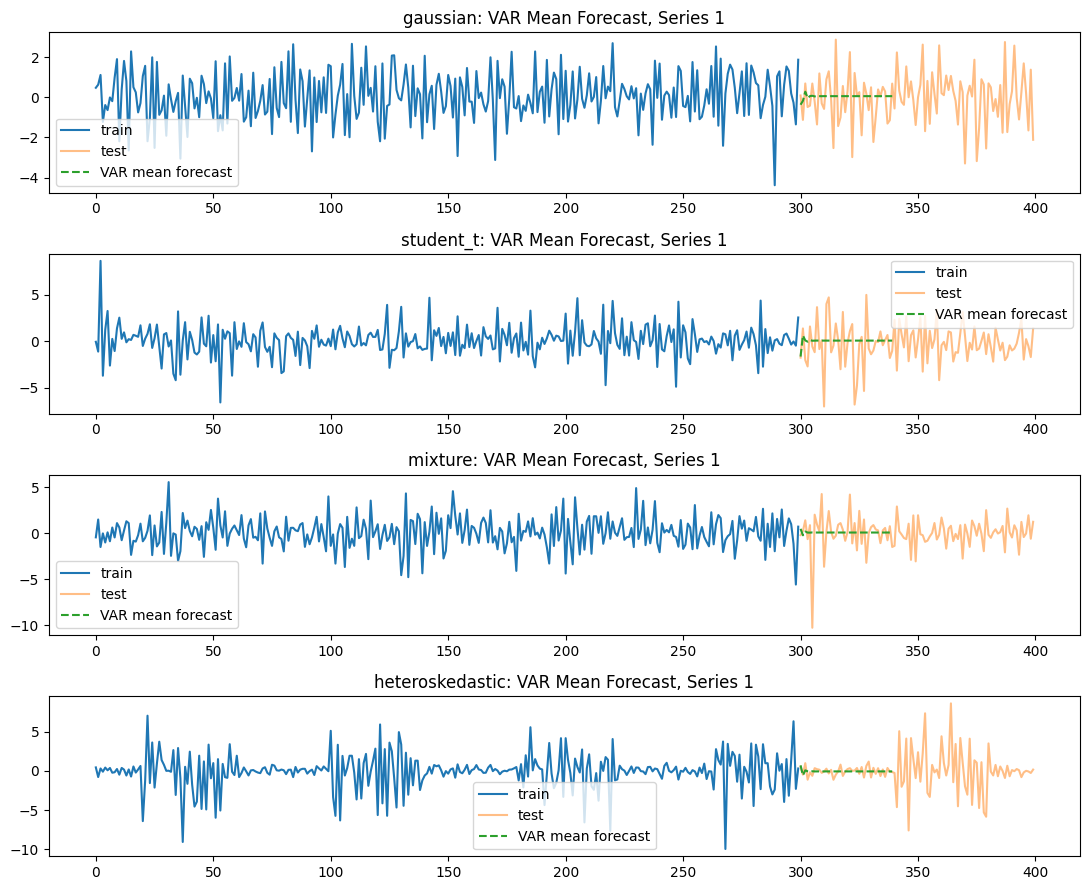

In [4]:
fig, axes = plt.subplots(
    len(dgp_names),
    1,
    figsize=(11, 9),
    sharex=False,
)

for ax, name in zip(axes, dgp_names):
    y_train = datasets[name]["y_train"]
    y_test = datasets[name]["y_test"]
    mean_forecast = forecast_rows[name]

    x_train = np.arange(len(y_train))
    x_test = np.arange(len(y_train), len(y_train) + horizon)

    ax.plot(x_train, y_train[:, 0], label="train")
    ax.plot(
        np.arange(len(y_train), len(y_train) + len(y_test)),
        y_test[:, 0],
        label="test",
        alpha=0.5,
    )
    ax.plot(x_test, mean_forecast[:, 0], linestyle="--", label="VAR mean forecast")
    ax.set_title(f"{name}: VAR Mean Forecast, Series 1")
    ax.legend()

plt.tight_layout()
plt.show()

## DeepAR Stub

DeepAR fitting will be added later after the VAR, residual, innovation, and calibration pipeline is validated.

The intended role of DeepAR is to provide a modern deep probabilistic forecasting baseline. However, the thesis contribution is not the DeepAR architecture itself. DeepAR will be used to test whether the innovation-modeling and calibration workflow can extend beyond a classical VAR forecasting backbone.

Future DeepAR workflow:

1. Load the same simulated DGP datasets.
2. Construct windowed context/target datasets.
3. Train a DeepAR-style recurrent probabilistic forecaster.
4. Extract forecast errors or residual-like prediction errors.
5. Compare DeepAR predictive distributions against VAR-based innovation models.
6. Evaluate calibration using the same coverage, PIT, ECE, CRPS, and energy score metrics.

In [6]:
run_dir = make_run_dir(
    base_dir=ROOT / "logs" / "experiments",
    run_name="02_var_deepar_fit",
)

metrics = {
    "notebook": "02_var_deepar_fit",
    "models_fit": ["VAR"],
    "models_stubbed": ["DeepAR"],
    "dgp_names": dgp_names,
    "lags": lags,
    "n_train": n_train,
    "n_test": n_test,
    "all_var_stable": bool(fit_summary_df["stable"].all()),
}

save_metrics_json(
    metrics,
    run_dir / "fit_config.json",
)

print("Saved model outputs to:", model_dir)
print("Saved tables to:", table_dir)
print("Saved logs to:", run_dir)

Saved model outputs to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/models/02_var_deepar_fit
Saved tables to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/results/tables/02_var_deepar_fit
Saved logs to: /Users/jonathanma/Desktop/MSEnotes/Masters_Thesis/ThesisProject/innovative-droBVAR/logs/experiments/20260518_173732_02_var_deepar_fit
